# 2026 COMP90042 Project


# Readme

If there is something to be noted for the marker, please mention here.

If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [45]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    DRIVE_DIR = Path("/content/drive/MyDrive/COMP90042/data")
except ImportError:
    IN_COLAB = False
    # Local: data/ folder next to this notebook
    DRIVE_DIR = Path("data")

print("Running in Colab:", IN_COLAB)
print("Data directory  :", DRIVE_DIR.resolve())


Running in Colab: False
Data directory  : /Users/yangjiesen/project/My Pro/COMP90042_2026-main/data


In [46]:
import json
from collections import Counter

required_files = [
    "train-claims.json",
    "dev-claims.json",
    "test-claims-unlabelled.json",
    "evidence.json",
    "dev-claims-baseline.json",
]

for file_name in required_files:

    file_path = DRIVE_DIR / file_name

    print(file_name, "exists:", file_path.exists())

def load_json(path):

    with open(path, "r", encoding="utf-8") as f:

        return json.load(f)

train_claims = load_json(DRIVE_DIR / "train-claims.json")
dev_claims = load_json(DRIVE_DIR / "dev-claims.json")
test_claims = load_json(DRIVE_DIR / "test-claims-unlabelled.json")
evidence = load_json(DRIVE_DIR / "evidence.json")
dev_baseline = load_json(DRIVE_DIR / "dev-claims-baseline.json")

print("\n===Dataset Overvieww===\n")
print("Train claims:", len(train_claims))
print("Dev claims:", len(dev_claims))
print("Test claims:", len(test_claims))
print("Evidence:", len(evidence))
print("Dev baseline:", len(dev_baseline))


train-claims.json exists: True
dev-claims.json exists: True
test-claims-unlabelled.json exists: True
evidence.json exists: True
dev-claims-baseline.json exists: True

===Dataset Overvieww===

Train claims: 1228
Dev claims: 154
Test claims: 153
Evidence: 1208827
Dev baseline: 154


In [47]:
LABELS = ["SUPPORTS", "REFUTES", "NOT_ENOUGH_INFO", "DISPUTED"]

label_id = {label: idx for idx, label in enumerate(LABELS)}
id_label = {idx: label for label, idx in label_id.items()}

print("===Label mapping===\n")

for label in LABELS:

    print(f"{label:16s} -> {label_id[label]}")

===Label mapping===

SUPPORTS         -> 0
REFUTES          -> 1
NOT_ENOUGH_INFO  -> 2
DISPUTED         -> 3


In [48]:
def validate_labelled_claims(claims, split_name):

    required_fields = {"claim_text", "claim_label", "evidences"}
    problems = []

    for claim_id, item in claims.items():

        missing_fields = required_fields.difference(item.keys())

        if missing_fields:

            problems.append((claim_id, sorted(missing_fields)))

        elif item["claim_label"] not in label_id:

            problems.append((claim_id, ["invalid claim_label"]))

        elif not isinstance(item["evidences"], list):

            problems.append((claim_id, ["evidences is not a list"]))

        elif len(item["evidences"]) == 0:

            problems.append((claim_id, ["empty evidences"]))

    if problems:

        print(f"{split_name} has format problems:")
        print(problems[:5])

    else:

        print(f"{split_name}: format OK ({len(claims):,} claims)")


def validate_unlabelled_claims(claims, split_name):

    problems = []

    for claim_id, item in claims.items():

        if "claim_text" not in item:

            problems.append((claim_id, ["missing claim_text"]))

    if problems:

        print(f"{split_name} has format problems:")
        print(problems[:5])

    else:

        print(f"{split_name}: format OK ({len(claims):,} claims)")

print("===Dataset Inspection===\n")
validate_labelled_claims(train_claims, "Train")
validate_labelled_claims(dev_claims, "Dev")
validate_unlabelled_claims(test_claims, "Test")



===Dataset Inspection===

Train: format OK (1,228 claims)
Dev: format OK (154 claims)
Test: format OK (153 claims)


=== Label Distribution ===



,Label,Train,Dev,Train %,Dev %
0,SUPPORTS,519,68,42.263844,44.155844
2,NOT_ENOUGH_INFO,386,41,31.433225,26.623377
1,REFUTES,199,27,16.205212,17.532468
3,DISPUTED,124,18,10.097720,11.688312


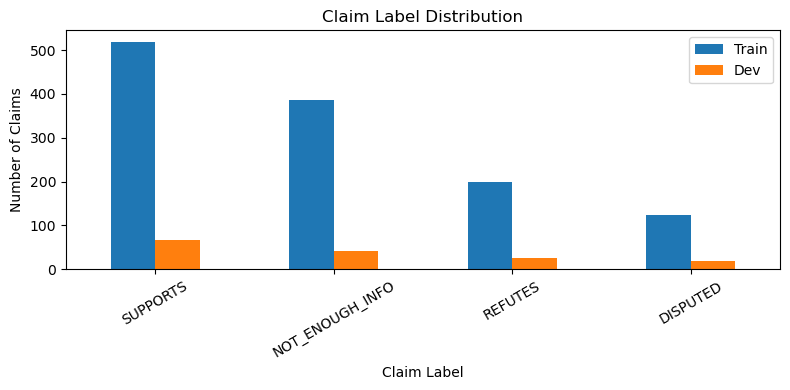

=== Gold Evidence Count Summary ===


,Split,Min,Max,Mean,Median
0,Train,1,5,3.356678,3.0
1,Dev,1,5,3.188312,3.0


=== Gold Evidence Count Distribution ===


,Train,Dev
Number of Gold Evidences,,
1,210,31
2,223,29
3,191,26
4,127,16
5,477,52


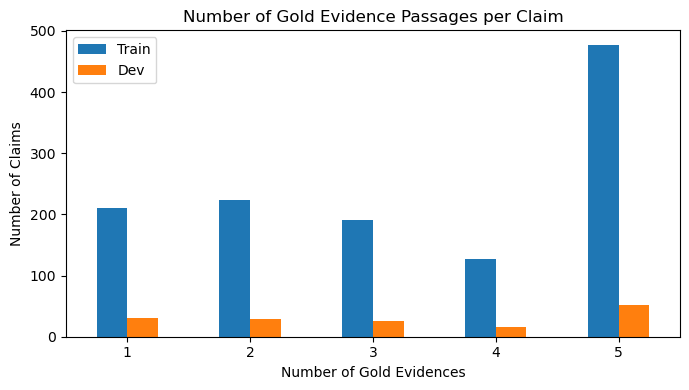

=== Claim Length Statistics ===


,Split,Min,Max,Mean,Median
0,Train,4,67,20.097720,19.0
1,Dev,4,65,21.084416,18.0


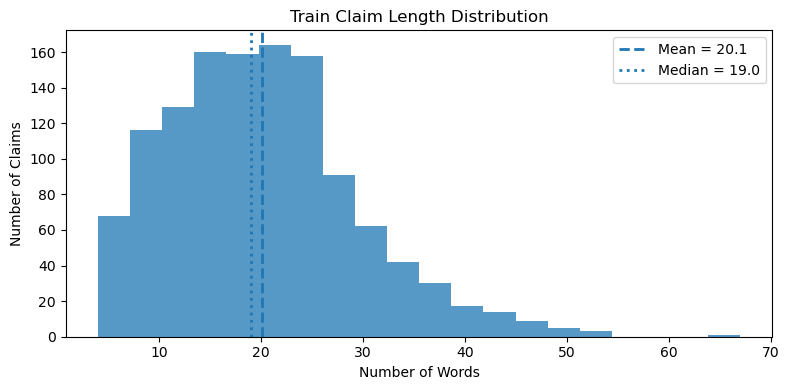

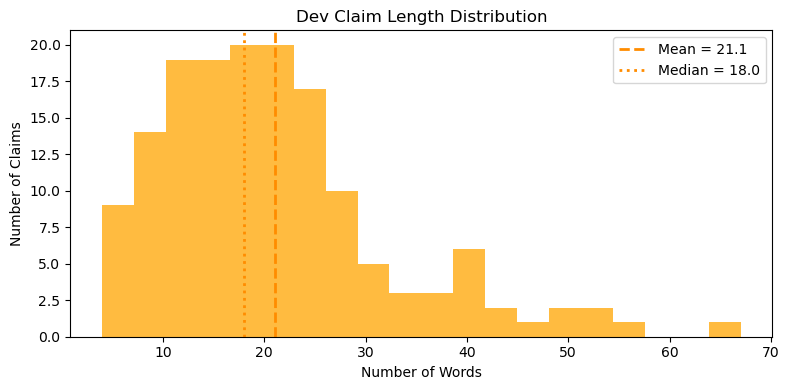

In [49]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====Label Distribution====

train_counts = Counter(item["claim_label"] for item in train_claims.values())
dev_counts = Counter(item["claim_label"] for item in dev_claims.values())

label_table = pd.DataFrame({
    "Label": LABELS,
    "Train": [train_counts[label] for label in LABELS],
    "Dev": [dev_counts[label] for label in LABELS],
})

label_table["Train %"] = label_table["Train"] / len(train_claims) * 100
label_table["Dev %"] = label_table["Dev"] / len(dev_claims) * 100

# Sort labels by train count, high to low
label_table = label_table.sort_values("Train", ascending=False)

print("=== Label Distribution ===\n")

display(label_table)

label_table.set_index("Label")[["Train", "Dev"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Claim Label Distribution")
plt.xlabel("Claim Label")
plt.ylabel("Number of Claims")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ====Gold Evidence Counts====

train_evidence_counts = [
    len(item["evidences"]) for item in train_claims.values()
]

dev_evidence_counts = [
    len(item["evidences"]) for item in dev_claims.values()
]

evidence_count_summary = pd.DataFrame({
    "Split": ["Train", "Dev"],
    "Min": [min(train_evidence_counts), min(dev_evidence_counts)],
    "Max": [max(train_evidence_counts), max(dev_evidence_counts)],
    "Mean": [np.mean(train_evidence_counts), np.mean(dev_evidence_counts)],
    "Median": [np.median(train_evidence_counts), np.median(dev_evidence_counts)],
})

print("=== Gold Evidence Count Summary ===")

display(evidence_count_summary)

evidence_count_table = pd.DataFrame({
    "Train": pd.Series(train_evidence_counts).value_counts().sort_index(),
    "Dev": pd.Series(dev_evidence_counts).value_counts().sort_index(),
}).fillna(0).astype(int)

evidence_count_table.index.name = "Number of Gold Evidences"

print("=== Gold Evidence Count Distribution ===")

display(evidence_count_table)

evidence_count_table.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Number of Gold Evidence Passages per Claim")
plt.xlabel("Number of Gold Evidences")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ===Claim Text Lengths===

train_claim_lengths = [
    len(item["claim_text"].split()) for item in train_claims.values()
]

dev_claim_lengths = [
    len(item["claim_text"].split()) for item in dev_claims.values()
]

claim_length_table = pd.DataFrame({
    "Split": ["Train", "Dev"],
    "Min": [min(train_claim_lengths), min(dev_claim_lengths)],
    "Max": [max(train_claim_lengths), max(dev_claim_lengths)],
    "Mean": [np.mean(train_claim_lengths), np.mean(dev_claim_lengths)],
    "Median": [np.median(train_claim_lengths), np.median(dev_claim_lengths)],
})

print("=== Claim Length Statistics ===")

display(claim_length_table)

# Use the same bins for both plots so they are comparable
x_min = min(min(train_claim_lengths), min(dev_claim_lengths))
x_max = max(max(train_claim_lengths), max(dev_claim_lengths))
bins = np.linspace(x_min, x_max, 21)

# ==Train claim length plot==

train_mean = np.mean(train_claim_lengths)
train_median = np.median(train_claim_lengths)

plt.figure(figsize=(8, 4))
plt.hist(train_claim_lengths, bins=bins, alpha=0.75)

plt.axvline(
    train_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {train_mean:.1f}"
)

plt.axvline(
    train_median,
    linestyle=":",
    linewidth=2,
    label=f"Median = {train_median:.1f}"
)

plt.title("Train Claim Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Claims")
plt.legend()
plt.tight_layout()
plt.show()

# ==Dev claim length plot==

dev_mean = np.mean(dev_claim_lengths)
dev_median = np.median(dev_claim_lengths)

plt.figure(figsize=(8, 4))
plt.hist(dev_claim_lengths, bins=bins, alpha=0.75, color="orange")

plt.axvline(
    dev_mean,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {dev_mean:.1f}"
)

plt.axvline(
    dev_median,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label=f"Median = {dev_median:.1f}"
)

plt.title("Dev Claim Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Claims")
plt.legend()
plt.tight_layout()
plt.show()


In [50]:
import re

def clean_text(text):
    """
    Light text cleaning.
    Only normalise whitespace; keep numbers, units, punctuation, and symbols.
    """
    text = str(text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()

evidence_ids = list(evidence.keys())
evidence_texts = [clean_text(evidence[eid]) for eid in evidence_ids]

evidence_id_to_index = {
    eid: idx for idx, eid in enumerate(evidence_ids)
}

evidence_lengths = [
    len(text.split()) for text in evidence_texts
]

empty_evidence_count = sum(
    1 for text in evidence_texts if text == ""
)

print("=== Evidence Corpus Overview ===\n")
print(f"Evidence passages : {len(evidence_texts):,}")
print(f"Empty passages    : {empty_evidence_count:,}")
print(f"Mean length       : {np.mean(evidence_lengths):.1f} words")
print(f"Median length     : {np.median(evidence_lengths):.1f} words")
print(f"Max length        : {max(evidence_lengths)} words")

=== Evidence Corpus Overview ===

Evidence passages : 1,208,827
Empty passages    : 0
Mean length       : 19.7 words
Median length     : 18.0 words
Max length        : 479 words


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [51]:
import importlib.util
import subprocess
import sys
import os
import random
import warnings

required_packages = {
    "torch": "torch",
    "transformers": "transformers",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
}

missing_packages = []

for module_name, package_name in required_packages.items():

    if importlib.util.find_spec(module_name) is None:

        missing_packages.append(package_name)

if missing_packages:

    print("Installing missing packages:", missing_packages)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", *missing_packages
    ])

else:

    print("All modelling packages are already installed.")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

# eval.py: Colab 在 Drive，本地在项目根目录
if IN_COLAB:
    EVAL_PATH = Path("/content/drive/MyDrive/COMP90042/eval.py")
else:
    EVAL_PATH = Path("eval.py")

print("Evaluation script exists:", EVAL_PATH.exists())


All modelling packages are already installed.
Using device: cpu
Evaluation script exists: True


In [52]:
TOP_K = 5
TFIDF_MAX_FEATURES = 300_000
TFIDF_CANDIDATE_K = 300
PRIOR_TOP_N = 20
PRIOR_WEIGHT = 0.25

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 384
BATCH_SIZE = 8
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01

FORCE_RETRAIN_BERT = False
TRAIN_FINAL_ON_TRAIN_DEV = False

# Checkpoint 路径：Colab 保存到 Drive，本地保存在项目根目录
if IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/COMP90042")
else:
    PROJECT_ROOT = Path(".")

TRAIN_CKPT_PATH = str(PROJECT_ROOT / "best_bert_classifier.pt")
FINAL_CKPT_PATH = str(PROJECT_ROOT / "final_bert_classifier.pt")
DEV_PRED_PATH = str(PROJECT_ROOT / "dev-claims-predictions.json")
BASELINE_PRED_PATH = str(PROJECT_ROOT / "dev-claims-baseline-predictions.json")
TEST_PRED_PATH = str(PROJECT_ROOT / "test-claims-predictions.json")

print("=== Hyperparameters ===")
print(f"TOP_K                    : {TOP_K}")
print(f"TFIDF_MAX_FEATURES       : {TFIDF_MAX_FEATURES}")
print(f"TFIDF_CANDIDATE_K        : {TFIDF_CANDIDATE_K}")
print(f"PRIOR_TOP_N              : {PRIOR_TOP_N}")
print(f"PRIOR_WEIGHT             : {PRIOR_WEIGHT}")
print(f"MODEL_NAME               : {MODEL_NAME}")
print(f"MAX_LENGTH               : {MAX_LENGTH}")
print(f"BATCH_SIZE               : {BATCH_SIZE}")
print(f"NUM_EPOCHS               : {NUM_EPOCHS}")
print(f"FORCE_RETRAIN_BERT       : {FORCE_RETRAIN_BERT}")
print(f"TRAIN_FINAL_ON_TRAIN_DEV : {TRAIN_FINAL_ON_TRAIN_DEV}")



=== Hyperparameters ===
TOP_K                    : 5
TFIDF_MAX_FEATURES       : 300000
TFIDF_CANDIDATE_K        : 300
PRIOR_TOP_N              : 20
PRIOR_WEIGHT             : 0.25
MODEL_NAME               : bert-base-uncased
MAX_LENGTH               : 384
BATCH_SIZE               : 8
NUM_EPOCHS               : 4
FORCE_RETRAIN_BERT       : False
TRAIN_FINAL_ON_TRAIN_DEV : False


In [53]:
class EvidenceRetriever:
    """
    Stage 1: TF-IDF retrieves top candidate evidence passages from the full corpus.
    Stage 2: Similar labelled training claims boost their gold evidence passages.
    """

    def __init__(self, evidence_ids, evidence_texts, clean_fn=clean_text):
        self.evidence_ids = list(evidence_ids)
        self.evidence_texts = list(evidence_texts)
        self.clean_fn = clean_fn
        self.evidence_id_to_index = {
            eid: idx for idx, eid in enumerate(self.evidence_ids)
        }
        self.vectorizer = None
        self.evidence_matrix = None
        self.prior_claim_ids = []
        self.prior_claim_matrix = None
        self.prior_claim_evidences = []

    def fit(self):
        self.vectorizer = TfidfVectorizer(
            max_features=TFIDF_MAX_FEATURES,
            min_df=2,
            analyzer="word",
            ngram_range=(1, 1),
            sublinear_tf=True,
            norm="l2",
            dtype=np.float32,
        )

        print("Start building TF-IDF evidence matrix")

        self.evidence_matrix = self.vectorizer.fit_transform(self.evidence_texts)

        print(f"TF-IDF matrix shape: {self.evidence_matrix.shape}")
        print(f"TF-IDF non-zero values: {self.evidence_matrix.nnz:,}")

        return self

    def set_supervised_prior(self, labelled_claims):
        self.prior_claim_ids = list(labelled_claims.keys())
        prior_texts = [
            self.clean_fn(labelled_claims[cid]["claim_text"])
            for cid in self.prior_claim_ids
        ]
        self.prior_claim_evidences = [
            labelled_claims[cid].get("evidences", [])
            for cid in self.prior_claim_ids
        ]
        self.prior_claim_matrix = self.vectorizer.transform(prior_texts)

        print(f"Loaded supervised prior from {len(self.prior_claim_ids):,} labelled claims.")

        return self

    @staticmethod
    def _top_from_sparse_row(row, k):
        data = row.data
        indices = row.indices

        if len(data) == 0:

            return np.array([], dtype=int), np.array([], dtype=np.float32)

        if len(data) > k:

            part = np.argpartition(data, -k)[-k:]
            part = part[np.argsort(data[part])[::-1]]

        else:

            part = np.argsort(data)[::-1]

        return indices[part], data[part]

    def retrieve_one(self, claim_text, top_k=TOP_K, candidate_k=TFIDF_CANDIDATE_K,
                     prior_top_n=PRIOR_TOP_N, prior_weight=PRIOR_WEIGHT):

        if self.vectorizer is None or self.evidence_matrix is None:

            raise RuntimeError("Call fit() before retrieval.")

        q_vec = self.vectorizer.transform([self.clean_fn(claim_text)])
        sparse_scores = q_vec @ self.evidence_matrix.T
        cand_idx, cand_scores = self._top_from_sparse_row(
            sparse_scores.getrow(0), candidate_k
        )

        combined_scores = {}

        if len(cand_idx) > 0:

            max_score = float(cand_scores.max())

            for idx, score in zip(cand_idx, cand_scores):

                score = float(score)

                if max_score > 0:

                    score = score / max_score

                combined_scores[int(idx)] = score

        if self.prior_claim_matrix is not None and prior_top_n > 0 and prior_weight > 0:

            prior_scores = q_vec @ self.prior_claim_matrix.T
            prior_idx, prior_vals = self._top_from_sparse_row(
                prior_scores.getrow(0), prior_top_n
            )
            max_prior = float(prior_vals.max()) if len(prior_vals) else 0.0

            for claim_idx, sim in zip(prior_idx, prior_vals):

                boost = float(sim) / max_prior if max_prior > 0 else float(sim)

                for ev_id in self.prior_claim_evidences[int(claim_idx)]:
                    ev_idx = self.evidence_id_to_index.get(ev_id)

                    if ev_idx is not None:

                        combined_scores[ev_idx] = combined_scores.get(ev_idx, 0.0) + prior_weight * boost

        if not combined_scores:

            return [self.evidence_ids[0]]

        ranked = sorted(combined_scores.items(), key=lambda item: item[1], reverse=True)

        return [self.evidence_ids[idx] for idx, _ in ranked[:top_k]]

    def retrieve_many(self, claims, desc="Retrieving", prior_weight=PRIOR_WEIGHT):
        retrieved = {}

        for claim_id, item in tqdm(list(claims.items()), desc=desc):

            retrieved[claim_id] = self.retrieve_one(
                item["claim_text"], prior_weight=prior_weight
            )

        return retrieved

In [54]:
retriever = EvidenceRetriever(evidence_ids, evidence_texts)
retriever.fit()
retriever.set_supervised_prior(train_claims)

def retrieval_fscore(predicted_evidences, gold_evidences):
    predicted_set = set(predicted_evidences)
    gold_set = set(gold_evidences)

    if not predicted_set or not gold_set:

        return 0.0

    correct = len(predicted_set & gold_set)

    if correct == 0:

        return 0.0

    precision = correct / len(predicted_set)
    recall = correct / len(gold_set)

    return 2 * precision * recall / (precision + recall)


def evaluate_retrieval_map(retrieved_map, gold_claims):
    scores = []

    for claim_id, item in gold_claims.items():

        scores.append(retrieval_fscore(retrieved_map.get(claim_id, []), item["evidences"]))

    return float(np.mean(scores)) if scores else 0.0


print("\nRetrieving dev evidence with full retriever ...")

dev_retrieved = retriever.retrieve_many(dev_claims, desc="Dev retrieval")
dev_retrieval_f = evaluate_retrieval_map(dev_retrieved, dev_claims)

print(f"Dev retrieval F-score: {dev_retrieval_f:.4f}")


Start building TF-IDF evidence matrix
TF-IDF matrix shape: (1208827, 233783)
TF-IDF non-zero values: 19,928,857
Loaded supervised prior from 1,228 labelled claims.

Retrieving dev evidence with full retriever ...


Dev retrieval:   0%|          | 0/154 [00:00<?, ?it/s]

Dev retrieval F-score: 0.1146


In [55]:
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)


def evidence_text_from_ids(ev_ids, evidence_dict, max_passages=TOP_K):

    texts = []

    for ev_id in ev_ids[:max_passages]:

        text = evidence_dict.get(ev_id, "")

        if text:

            texts.append(clean_text(text))

    return " [SEP] ".join(texts)


class ClaimEvidenceDataset(Dataset):
    """Dataset for BERT claim classification using claim + evidence text."""

    def __init__(self, claims, evidence_dict, tokenizer, retrieved=None,
                 use_gold=True, max_length=MAX_LENGTH):
        self.items = list(claims.items())
        self.evidence = evidence_dict
        self.tokenizer = tokenizer
        self.retrieved = retrieved or {}
        self.use_gold = use_gold
        self.max_length = max_length

    def __len__(self):

        return len(self.items)

    def __getitem__(self, idx):

        claim_id, item = self.items[idx]
        claim_text = clean_text(item["claim_text"])

        if self.use_gold and "evidences" in item:

            ev_ids = item["evidences"]

        else:

            ev_ids = self.retrieved.get(claim_id, [])

        ev_text = evidence_text_from_ids(ev_ids, self.evidence)
        encoded = self.tokenizer(
            claim_text,
            ev_text,
            max_length=self.max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        sample = {key: value.squeeze(0) for key, value in encoded.items()}
        sample["claim_id"] = claim_id

        if "claim_label" in item:

            sample["labels"] = torch.tensor(label_id[item["claim_label"]], dtype=torch.long)

        return sample


def make_class_weights(claims):

    label_ids = [label_id[item["claim_label"]] for item in claims.values()]
    counts = np.bincount(label_ids, minlength=len(LABELS)).astype(np.float32)
    weights = counts.sum() / (len(LABELS) * np.maximum(counts, 1.0))

    return torch.tensor(weights, dtype=torch.float32)


def build_model():

    return BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id_label,
        label2id=label_id,
    )


def move_batch_to_device(batch, device):

    tensor_batch = {}

    for key, value in batch.items():

        if key == "claim_id":

            continue

        tensor_batch[key] = value.to(device)

    return tensor_batch


In [56]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()
        labels = batch["labels"].to(device)
        inputs = move_batch_to_device(batch, device)
        inputs.pop("labels", None)

        outputs = model(**inputs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / max(len(loader), 1), correct / max(total, 1)


def evaluate_classifier(model, loader, device, criterion=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            labels = batch["labels"].to(device)
            inputs = move_batch_to_device(batch, device)
            inputs.pop("labels", None)

            outputs = model(**inputs)
            if criterion is not None:
                total_loss += criterion(outputs.logits, labels).item()

            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    mean_loss = total_loss / max(len(loader), 1) if criterion is not None else None
    accuracy = correct / max(total, 1)
    return mean_loss, accuracy, all_preds, all_labels


def fit_classifier(train_claims_for_fit, dev_claims_for_eval=None, checkpoint_path=TRAIN_CKPT_PATH):
    if os.path.exists(checkpoint_path) and not FORCE_RETRAIN_BERT:
        print(f"Loading existing checkpoint: {checkpoint_path}")
        model = build_model().to(DEVICE)
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        return model

    train_dataset = ClaimEvidenceDataset(train_claims_for_fit, evidence, tokenizer, use_gold=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    dev_loader = None
    if dev_claims_for_eval is not None:
        dev_dataset = ClaimEvidenceDataset(dev_claims_for_eval, evidence, tokenizer, use_gold=True)
        dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model().to(DEVICE)
    class_weights = make_class_weights(train_claims_for_fit).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps = NUM_EPOCHS * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(WARMUP_RATIO * total_steps),
        num_training_steps=total_steps,
    )

    print("Class weights:", class_weights.detach().cpu().numpy().round(3))
    best_score = -1.0

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, DEVICE
        )

        if dev_loader is not None:
            dev_loss, dev_acc, _, _ = evaluate_classifier(model, dev_loader, DEVICE, criterion)
            score = dev_acc
            print(
                f"Epoch {epoch}/{NUM_EPOCHS} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"dev_loss={dev_loss:.4f} dev_acc={dev_acc:.4f}"
            )
        else:
            score = -train_loss
            print(f"Epoch {epoch}/{NUM_EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f}")

        if score > best_score:
            best_score = score
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Saved checkpoint -> {checkpoint_path}")

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    return model


In [57]:
print("Fine-tuning BERT classifier on train claims with gold evidence ...")
model = fit_classifier(train_claims, dev_claims_for_eval=dev_claims, checkpoint_path=TRAIN_CKPT_PATH)
print("Classifier ready.")

Fine-tuning BERT classifier on train claims with gold evidence ...
Loading existing checkpoint: best_bert_classifier.pt


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Classifier ready.


# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [58]:
print("Generating TF-IDF + majority-label baseline predictions ...")

baseline_retrieved = retriever.retrieve_many(
    dev_claims,
    desc="Baseline dev retrieval",
    prior_weight=0.0,
)

majority_label = Counter(item["claim_label"] for item in train_claims.values()).most_common(1)[0][0]

print("Majority label:", majority_label)

baseline_predictions = {}

for claim_id, item in dev_claims.items():

    baseline_predictions[claim_id] = {
        "claim_text": item["claim_text"],
        "claim_label": majority_label,
        "evidences": baseline_retrieved[claim_id],
    }

with open(BASELINE_PRED_PATH, "w", encoding="utf-8") as f:
    json.dump(baseline_predictions, f, indent=2, ensure_ascii=False)

print("Saved baseline predictions ->", BASELINE_PRED_PATH)

if EVAL_PATH.exists():

    result = subprocess.run(
        [sys.executable, str(EVAL_PATH), "--predictions", BASELINE_PRED_PATH,
         "--groundtruth", str(DRIVE_DIR / "dev-claims.json")],
        capture_output=True,
        text=True,
    )

    print("\n=== Baseline Official Evaluation ===")
    print(result.stdout)

    if result.returncode != 0:

        print(result.stderr)
else:

    print("eval.py not found. Please place eval.py in:", PROJECT_ROOT)


Generating TF-IDF + majority-label baseline predictions ...


Baseline dev retrieval:   0%|          | 0/154 [00:00<?, ?it/s]

Majority label: SUPPORTS
Saved baseline predictions -> dev-claims-baseline-predictions.json

=== Baseline Official Evaluation ===
Evidence Retrieval F-score (F)    = 0.09183673469387757
Claim Classification Accuracy (A) = 0.44155844155844154
Harmonic Mean of F and A          = 0.1520496894409938



In [59]:
# ── Section 3-2: Prediction Helpers ─────────────────────────────────────────
def predict_claim_labels(model, claims, retrieved_map):
    dataset = ClaimEvidenceDataset(
        claims,
        evidence,
        tokenizer,
        retrieved=retrieved_map,
        use_gold=False,
    )
    
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model.eval()
    label_predictions = {}
    with torch.no_grad():

        for batch in tqdm(loader, desc="Predicting"):

            claim_ids = batch["claim_id"]
            inputs = move_batch_to_device(batch, DEVICE)
            inputs.pop("labels", None)
            outputs = model(**inputs)
            pred_ids = outputs.logits.argmax(dim=-1).cpu().tolist()

            for claim_id, pred_id in zip(claim_ids, pred_ids):

                label_predictions[claim_id] = id_label[pred_id]

    return label_predictions


def write_prediction_file(path, claims, label_predictions, retrieved_map, include_claim_text=True):
    output = {}

    for claim_id, item in claims.items():

        entry = {
            "claim_label": label_predictions[claim_id],
            "evidences": retrieved_map[claim_id],
        }

        if include_claim_text:

            entry["claim_text"] = item["claim_text"]

        output[claim_id] = entry

    with open(path, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=2, ensure_ascii=False)

    print(f"Saved {len(output):,} predictions -> {path}")

    return output

In [60]:
print("Generating full-system development predictions ...")

dev_label_predictions = predict_claim_labels(model, dev_claims, dev_retrieved)

dev_predictions = write_prediction_file(
    DEV_PRED_PATH,
    dev_claims,
    dev_label_predictions,
    dev_retrieved,
    include_claim_text=True,
)

if EVAL_PATH.exists():
    result = subprocess.run(
        [sys.executable, str(EVAL_PATH), "--predictions", DEV_PRED_PATH,
         "--groundtruth", str(DRIVE_DIR / "dev-claims.json")],
        capture_output=True,
        text=True,
    )

    print("\n=== Full System Official Evaluation ===")
    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
else:
    
    print("eval.py not found. Please place eval.py in:", PROJECT_ROOT)


Generating full-system development predictions ...


Predicting:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 154 predictions -> dev-claims-predictions.json

=== Full System Official Evaluation ===
Evidence Retrieval F-score (F)    = 0.11457431457431458
Claim Classification Accuracy (A) = 0.4155844155844156
Harmonic Mean of F and A          = 0.17962657919108657



In [61]:
true_labels = [dev_claims[cid]["claim_label"] for cid in dev_claims]
pred_labels = [dev_predictions[cid]["claim_label"] for cid in dev_claims]

print("=== Classification Report ===")
print(classification_report(true_labels, pred_labels, labels=LABELS, zero_division=0))

print("=== Confusion Matrix ===")

cm = confusion_matrix(true_labels, pred_labels, labels=LABELS)

print("Rows=true labels, columns=predicted labels")
print(" " * 20 + " ".join(f"{label[:6]:>8}" for label in LABELS))

for label, row in zip(LABELS, cm):

    print(f"{label[:18]:<20}" + " ".join(f"{value:>8}" for value in row))

retrieval_scores = [
    retrieval_fscore(dev_predictions[cid]["evidences"], dev_claims[cid]["evidences"])
    for cid in dev_claims
]

print("\n=== Retrieval Diagnostics ===")
print(f"Mean retrieval F-score: {np.mean(retrieval_scores):.4f}")
print(f"Claims with at least one correct evidence: {sum(s > 0 for s in retrieval_scores)}/{len(retrieval_scores)}")


=== Classification Report ===
                 precision    recall  f1-score   support

       SUPPORTS       0.57      0.53      0.55        68
        REFUTES       0.43      0.22      0.29        27
NOT_ENOUGH_INFO       0.35      0.41      0.38        41
       DISPUTED       0.17      0.28      0.21        18

       accuracy                           0.42       154
      macro avg       0.38      0.36      0.36       154
   weighted avg       0.44      0.42      0.42       154

=== Confusion Matrix ===
Rows=true labels, columns=predicted labels
                      SUPPOR   REFUTE   NOT_EN   DISPUT
SUPPORTS                  36        4       20        8
REFUTES                    8        6        5        8
NOT_ENOUGH_INFO           12        4       17        8
DISPUTED                   7        0        6        5

=== Retrieval Diagnostics ===
Mean retrieval F-score: 0.1146
Claims with at least one correct evidence: 58/154


In [ ]:
# Used for participating in the ranking

if TRAIN_FINAL_ON_TRAIN_DEV:

    combined_claims = {**train_claims, **dev_claims}

    print("Training final classifier on train+dev gold evidence ...")

    final_model = fit_classifier(
        combined_claims,
        dev_claims_for_eval=None,
        checkpoint_path=FINAL_CKPT_PATH,
    )

    print("Updating supervised retrieval prior to train+dev ...")

    retriever.set_supervised_prior(combined_claims)

else:

    final_model = model

    print("Using train-only classifier and train-only retrieval prior for test prediction.")

print("Retrieving evidence for test claims ...")

test_retrieved = retriever.retrieve_many(test_claims_unlabelled, desc="Test retrieval")

print("Predicting test labels ...")

test_label_predictions = predict_claim_labels(final_model, test_claims_unlabelled, test_retrieved)

TEST_PRED_PATH = "test-claims-predictions.json"
test_predictions = write_prediction_file(
    TEST_PRED_PATH,
    test_claims_unlabelled,
    test_label_predictions,
    test_retrieved,
    include_claim_text=False,
)
validate_prediction_dict(test_predictions, test_claims_unlabelled, "Test predictions")

print("Test prediction file is ready for optional leaderboard submission.")


## Object Oriented Programming codes here
You can use multiple code snippets. Just add more if needed